# QuRad vs Python PyRadiomics Comparison

This notebook compares radiomics features extracted by:
1. **QuRad** - QuPath Groovy extension
2. **PyRadiomics** - Python package

## Setup

### Loading Example Data into QuPath

1. **Open QuPath**
2. **File > Open** and select: `QuRad/example_data/image.tif`
3. **Run cell detection** (e.g., StarDist, Cellpose, or QuPath's built-in detector)
4. **Run QuRad script**: `Automate > Script editor > Open > QuPath_Radiomics_v2.groovy`
5. **Click Run** - This generates a CSV file in `/radiomics/`

The example data includes:

**Breast cancer data**

- `image.tif` - RGB H&E image (converted to grayscale during processing)
- `labels.tif` - Labeled mask (uint16, each cell has unique integer value 1, 2, 3...)
- `cell_detections.geojson` - Cell detections to be imported in QuPath

**GBM data**
- tbd

## Workflow
1. Load example image and labels
2. Run Python pyradiomics on the image + labeled mask
3. Compare feature values with QuRad results

## Loading

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
import os
from pathlib import Path
import SimpleITK as sitk
from radiomics import featureextractor
import warnings
warnings.filterwarnings('ignore')

In [2]:
NOTEBOOK_DIR = Path(os.getcwd())  # Current working directory
BASE_DIR = Path("/Users/tamara/Desktop/PyRadiomics")
QUPATH_RADIOMICS_DIR = BASE_DIR / "Qupath" / "radiomics"

# Example data gbm
#IMAGE_PATH = EXAMPLE_DATA_DIR / "ILR192-11-17-36-45_8367_10109_z0_t0.tif"
#LABELS_PATH = EXAMPLE_DATA_DIR / "ILR192-11-17-36-45_8367_10109_z0_t0_cp_masks.tif"

# Example data breast_cancer
EXAMPLE_DATA_DIR = BASE_DIR / "QuRad" / "example_data" / "breast_cancer"
IMAGE_PATH = EXAMPLE_DATA_DIR / "ytma10_010704_benign1_ccd.tif"
LABELS_PATH = EXAMPLE_DATA_DIR / "ytma10_010704_benign1_ccd_labels.tif"

QURAD_CSV_DIR = QUPATH_RADIOMICS_DIR

print(f"Example data directory: {EXAMPLE_DATA_DIR}")
print(f"Image: {IMAGE_PATH}")
print(f"Labels: {LABELS_PATH}")
print(f"QuRad results directory: {QURAD_CSV_DIR}")

Example data directory: /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/breast_cancer
Image: /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/breast_cancer/ytma10_010704_benign1_ccd.tif
Labels: /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/breast_cancer/ytma10_010704_benign1_ccd_labels.tif
QuRad results directory: /Users/tamara/Desktop/PyRadiomics/Qupath/radiomics


In [3]:
# Load example image and labels
if not IMAGE_PATH.exists() or not LABELS_PATH.exists():
    print("✗ Example data not found!")
    print(f"  Expected:")
    print(f"    Image: {IMAGE_PATH}")
    print(f"    Labels: {LABELS_PATH}")
    print(f"\n  Please ensure the example data files exist.")
else:
    # Load label mask (uint16 grayscale)
    labels = np.array(Image.open(LABELS_PATH)).astype(np.int32)
    print(f"✓ Loaded label mask")
    print(f"  Shape: {labels.shape}")
    print(f"  Dtype: {labels.dtype}")
    
    unique_labels = np.unique(labels)
    # Exclude background (label 0)
    cell_labels = unique_labels[unique_labels > 0]
    print(f"  Unique labels (including background): {len(unique_labels)}")
    print(f"  Cell labels: {len(cell_labels)}")
    print(f"  Label range: {cell_labels.min()} to {cell_labels.max()}")
    
    # Load image (will be converted to grayscale later)
    img = np.array(Image.open(IMAGE_PATH))
    print(f"\n✓ Loaded image")
    print(f"  Shape: {img.shape}")
    print(f"  Dtype: {img.dtype}")

✓ Loaded label mask
  Shape: (768, 896)
  Dtype: int32
  Unique labels (including background): 411
  Cell labels: 410
  Label range: 1 to 410

✓ Loaded image
  Shape: (768, 896, 3)
  Dtype: uint8


## Exporting mask for QuPath

Save labels.tif as cell_detections.geojson

In [4]:
import json
from skimage import measure
from shapely.geometry import Polygon, MultiPolygon, mapping

OUTPUT_GEOJSON = EXAMPLE_DATA_DIR / "cell_detections.geojson"

features = []

for label_id in cell_labels:
    binary = (labels == label_id).astype(np.uint8)

    # Extract contours at pixel-accurate boundary
    contours = measure.find_contours(binary, level=0.5)

    polygons = []
    for contour in contours:
        # contour is (row, col) → convert to (x, y)
        poly = Polygon(contour[:, ::-1])

        # Filter tiny artifacts
        if poly.area >= 5:
            polygons.append(poly)

    if not polygons:
        continue

    geom = polygons[0] if len(polygons) == 1 else MultiPolygon(polygons)

    features.append({
        "type": "Feature",
        "geometry": mapping(geom),
        "properties": {
            "label_id": int(label_id),
            "object_type": "detection"
        }
    })

geojson = {
    "type": "FeatureCollection",
    "features": features
}

with open(OUTPUT_GEOJSON, "w") as f:
    json.dump(geojson, f)

print(f"✓ Exported {len(features)} cell detections")
print(f"→ {OUTPUT_GEOJSON}")


✓ Exported 410 cell detections
→ /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/breast_cancer/cell_detections.geojson


## Configure PyRadiomics

Set up the feature extractor with settings matching QuRad.

In [5]:
# Configure pyradiomics to match QuRad settings
settings = {
    'binWidth': 25,  # Same as QuRad
    'resampledPixelSpacing': None,  # No resampling
    'interpolator': sitk.sitkBSpline,
    'force2D': True,
    'force2Ddimension': 0,
    'normalize': False,
    'normalizeScale': 1,
    'removeOutliers': None,
    'voxelArrayShift': 0,
}

# Initialize the feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)

# Enable feature classes matching QuRad
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('shape2D')
extractor.enableFeatureClassByName('glcm')
extractor.enableFeatureClassByName('glrlm')
extractor.enableFeatureClassByName('glszm')
extractor.enableFeatureClassByName('ngtdm')
extractor.enableFeatureClassByName('gldm')

print("PyRadiomics Feature Extractor configured")
print(f"\nEnabled feature classes:")
for cls in extractor.enabledFeatures.keys():
    print(f"  - {cls}")

PyRadiomics Feature Extractor configured

Enabled feature classes:
  - firstorder
  - shape2D
  - glcm
  - glrlm
  - glszm
  - ngtdm
  - gldm


## Step 3: Extract PyRadiomics Features

Extract features for each labeled cell in the mask.

In [6]:
def extract_features_for_label(image_sitk, labels_sitk, label_value):
    """Extract pyradiomics features for a single label."""
    try:
        # Create binary mask for this label
        mask = sitk.Cast(labels_sitk == label_value, sitk.sitkInt32)
        
        # Check if mask has any pixels
        mask_array = sitk.GetArrayFromImage(mask)
        if mask_array.sum() == 0:
            return None
        
        # Calculate centroid from mask for spatial matching
        y_coords, x_coords = np.where(mask_array[0] > 0)  # Get coordinates (z, y, x) -> [0] for first slice
        if len(y_coords) == 0:
            return None
        centroid_y = float(np.mean(y_coords))
        centroid_x = float(np.mean(x_coords))
        
        # Extract features
        result = extractor.execute(image_sitk, mask, label=1)
        
        # Filter to only radiomics features (exclude diagnostics)
        features = {k: float(v) for k, v in result.items() 
                   if not k.startswith('diagnostics_')}
        
        # Add centroid coordinates for spatial matching with QuRad
        features['CentroidX'] = centroid_x
        features['CentroidY'] = centroid_y
        
        return features
    except Exception as e:
        return None

In [7]:
# Extract features for all labeled cells
pyrad_results = []

if 'img' in dir() and 'labels' in dir():
    # Convert to grayscale using same method as QuRad (luminance conversion)
    if len(img.shape) == 3 and img.shape[2] == 3:
        # QuRad uses: 0.299*R + 0.587*G + 0.114*B
        gray_2d = (img[:,:,0] * 0.299 + 
                   img[:,:,1] * 0.587 + 
                   img[:,:,2] * 0.114).astype(np.float32)
        print(f"✓ Converted RGB to grayscale using luminance weights (matching QuRad)")
    elif len(img.shape) == 2:
        gray_2d = img.astype(np.float32)
        print(f"✓ Image is already grayscale")
    else:
        gray_2d = img.squeeze().astype(np.float32)
        print(f"✓ Squeezed image to 2D")
    
    # Add a dimension for SimpleITK (expects 3D for force2D)
    gray_3d = gray_2d[np.newaxis, :, :]
    labels_3d = labels[np.newaxis, :, :].astype(np.int32)
    
    image_sitk = sitk.GetImageFromArray(gray_3d)
    labels_sitk = sitk.GetImageFromArray(labels_3d)
    
    print(f"Image shape for PyRadiomics: {sitk.GetArrayFromImage(image_sitk).shape}")
    print(f"Labels shape for PyRadiomics: {sitk.GetArrayFromImage(labels_sitk).shape}")
    
    # Get all cell labels (exclude background)
    cell_labels = np.unique(labels)
    cell_labels = cell_labels[cell_labels > 0]
    total_cells = len(cell_labels)
    
    # Limit to first N cells for testing (remove or increase for full extraction)
    max_cells = min(1000, total_cells)  # Set to total_cells for all
    
    print(f"\nExtracting PyRadiomics features for {max_cells} cells...\n")
    
    for idx, label_value in enumerate(cell_labels[:max_cells]):
        features = extract_features_for_label(image_sitk, labels_sitk, label_value)
        
        if features:
            features['label'] = int(label_value)
            # Use label as cell_id since we don't have QuPath IDs
            features['cell_id'] = f"label_{label_value}"
            pyrad_results.append(features)
        
        # Progress update
        if (idx + 1) % 20 == 0:
            print(f"  Processed {idx + 1}/{max_cells} cells...")
    
    print(f"\n✓ Extracted features for {len(pyrad_results)} cells")
else:
    print("Please run previous cells to load the example data.")

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


✓ Converted RGB to grayscale using luminance weights (matching QuRad)
Image shape for PyRadiomics: (1, 768, 896)
Labels shape for PyRadiomics: (1, 768, 896)

Extracting PyRadiomics features for 410 cells...



GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

  Processed 20/410 cells...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

...

  Processed 380/410 cells...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

  Processed 400/410 cells...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated



✓ Extracted features for 410 cells


In [8]:
# Create DataFrame from PyRadiomics results
if pyrad_results:
    pyrad_df = pd.DataFrame(pyrad_results)
    print(f"PyRadiomics DataFrame shape: {pyrad_df.shape}")
    print(f"\nFeature classes extracted:")
    
    # Count features by class
    feature_counts = {}
    for col in pyrad_df.columns:
        if '_' in col and col not in ['label', 'cell_id']:
            prefix = col.split('_')[1]  # original_firstorder_X -> firstorder
            feature_counts[prefix] = feature_counts.get(prefix, 0) + 1
    
    for cls, count in sorted(feature_counts.items()):
        print(f"  {cls}: {count} features")
    
    print(f"\nTotal features: {sum(feature_counts.values())}")
    display(pyrad_df.head())

PyRadiomics DataFrame shape: (410, 106)

Feature classes extracted:
  firstorder: 18 features
  glcm: 24 features
  gldm: 14 features
  glrlm: 16 features
  glszm: 16 features
  ngtdm: 5 features
  shape2D: 9 features

Total features: 102


,original_shape2D_Elongation,original_shape2D_MajorAxisLength,original_shape2D_MaximumDiameter,original_shape2D_MeshSurface,original_shape2D_MinorAxisLength,original_shape2D_Perimeter,original_shape2D_PerimeterSurfaceRatio,original_shape2D_PixelSurface,original_shape2D_Sphericity,original_firstorder_10Percentile,...,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,CentroidX,CentroidY,label,cell_id
0,0.701700,33.351022,35.468296,597.5,23.402404,96.426407,0.161383,598.0,0.898624,113.593702,...,401.334448,6.352367,0.152709,0.040600,0.375727,0.007034,276.894649,289.926421,1,label_1
1,0.583385,33.982555,33.837849,518.5,19.824928,90.669048,0.174868,519.0,0.890267,98.068001,...,484.535645,6.812938,0.142579,0.033304,0.357421,0.004746,611.799615,398.780347,2,label_2
2,0.694449,30.356777,30.594117,500.5,21.081221,85.597980,0.171025,501.0,0.926496,97.309998,...,553.247505,6.915947,0.123774,0.027412,0.285212,0.004152,552.856287,403.976048,3,label_3
3,0.843890,26.879642,27.802878,476.5,22.683452,83.012193,0.174212,477.0,0.932169,89.947998,...,195.794549,24.760599,0.462439,0.031959,0.135052,0.012751,73.884696,414.144654,4,label_4
4,0.515537,33.840138,33.241540,455.5,17.445844,88.325902,0.193910,456.0,0.856566,101.792000,...,324.313596,11.794126,0.236256,0.040602,0.382165,0.008899,160.177632,638.912281,5,label_5


## Step 4: Load QuRad Results

In [11]:
# Load cell mapping (label ID -> QuPath ObjectID)
cell_mapping_path = BASE_DIR / "Qupath" / "exports" / "masks" / "cell_info.csv"

if cell_mapping_path.exists():
    cell_mapping = pd.read_csv(cell_mapping_path)
    print(f"✓ Loaded cell mapping: {len(cell_mapping)} cells")
    print(f"  Columns: {list(cell_mapping.columns)}")
    display(cell_mapping.head())
else:
    print(f"Cell mapping not found: {cell_mapping_path}")

✓ Loaded cell mapping: 410 cells
  Columns: ['label', 'cell_id', 'classification', 'x', 'y', 'width', 'height', 'area', 'centroid_x', 'centroid_y']


,label,cell_id,classification,x,y,width,height,area,centroid_x,centroid_y
0,1,c2c897d3-0a1c-40ae-a94e-e02b9252c18d,Unclassified,261.0,278.0,34.0,23.0,598.0,277.394653,290.426422
1,2,f1fd9206-00fa-46c6-87ea-1f33ad99d50d,Unclassified,596.0,386.0,30.0,25.0,519.0,612.299622,399.280334
2,3,f7e85319-d423-4211-b6a8-fe89ff50aafa,Unclassified,538.0,394.0,30.0,21.0,501.0,553.356262,404.476044
3,4,33ad606f-4cd1-4875-a1a7-fe9a77e144b5,Unclassified,62.0,402.0,25.0,25.0,477.0,74.384697,414.644653
4,5,0d15d120-5ff4-486e-8005-33bfbb812dcd,Unclassified,148.0,623.0,24.0,31.0,456.0,160.677628,639.412292


In [12]:
# Find the most recent QuRad CSV
radiomics_dir = QUPATH_RADIOMICS_DIR
qurad_files = sorted(radiomics_dir.glob("*.csv"), reverse=True)

if qurad_files:
    qurad_csv = qurad_files[0]
    print(f"Loading QuRad results from: {qurad_csv.name}")
    
    qurad_df = pd.read_csv(qurad_csv)
    print(f"QuRad DataFrame shape: {qurad_df.shape}")
    
    # Count features by class
    print(f"\nFeature classes:")
    feature_counts = {}
    for col in qurad_df.columns:
        if '_' in col and col not in ['ObjectID', 'ObjectType', 'Classification']:
            prefix = col.split('_')[0]
            feature_counts[prefix] = feature_counts.get(prefix, 0) + 1
    
    for cls, count in sorted(feature_counts.items()):
        print(f"  {cls}: {count} features")
    
    display(qurad_df.head())
else:
    print("No QuRad results found. Run QuPath_Radiomics_v2.groovy first.")

Loading QuRad results from: ytma10_010704_benign1_ccd_tif_radiomics_20251216_154854.csv
QuRad DataFrame shape: (411, 123)

Feature classes:
  firstorder: 19 features
  glcm: 23 features
  gldm: 15 features
  glrlm: 16 features
  glszm: 16 features
  ngtdm: 5 features
  shape: 16 features
  shape2D: 10 features


,Classification,ObjectID,ObjectType,firstorder_10Percentile,firstorder_90Percentile,firstorder_Energy,firstorder_Entropy,firstorder_InterquartileRange,firstorder_Kurtosis,firstorder_Maximum,...,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,shape_SphericalDisproportion,shape_Sphericity,shape_SurfaceArea,shape_SurfaceVolumeRatio,shape_VoxelVolume
0,Unclassified,8d89d871-3c2c-4e41-bbe6-f5b8c1eb55e1,Annotation,113.0,147.0,2784923.0,1.262036,18.0,2.615298,161.0,...,15.0,21.213203,21.213203,160.0,15.0,1.790493,0.558505,60.0,0.375000,160.0
1,Unclassified,42c22bed-98dd-42a0-8c64-06d19e0eaeb4,Annotation,119.0,157.0,6342812.0,1.540798,23.0,3.267990,168.0,...,21.0,28.319605,28.319605,336.0,19.0,1.515761,0.659734,80.0,0.238095,336.0
2,Unclassified,738e10ef-2ed9-4955-b46d-d0ad59e0d366,Annotation,72.0,116.0,2250003.0,1.504231,20.0,3.628430,145.0,...,21.0,27.018512,27.018512,255.0,17.0,1.802508,0.554783,76.0,0.298039,255.0
3,Unclassified,972d511d-b9db-4682-a3e9-b4b42a97316e,Annotation,80.0,113.0,885325.0,0.903932,18.0,2.223986,119.0,...,13.0,17.691806,17.691806,97.0,12.0,2.050966,0.487575,50.0,0.515464,97.0
4,Unclassified,c21cdba9-36d0-4835-9ba7-df0045566ba6,Annotation,129.0,166.0,4578728.0,1.360859,24.0,2.024419,177.0,...,13.0,25.553865,25.553865,209.0,13.0,1.865692,0.535994,70.0,0.334928,209.0


## Step 5: Compare Features

Map feature names between QuRad and PyRadiomics and compare values.

In [19]:
def compare_all_features(qurad_df, pyrad_df, cell_mapping):
    """Compare ALL features between QuRad and PyRadiomics automatically."""
    
    # Get all feature columns BEFORE merging
    qurad_feat_cols = [c for c in qurad_df.columns if '_' in c and c not in ['ObjectID', 'ObjectType', 'Classification']]
    pyrad_feat_cols = [c for c in pyrad_df.columns if '_' in c and c not in ['label', 'cell_id']]
    
    print(f"QuRad features: {len(qurad_feat_cols)}")
    print(f"PyRadiomics features: {len(pyrad_feat_cols)}\n")
    
    # Create feature mapping automatically (one-to-one mapping)
    feature_mapping = {}
    used_pyrad_features = set()  # Track which PyRadiomics features are already mapped
    
    for qurad_feat in qurad_feat_cols:
        parts = qurad_feat.split('_', 1)
        if len(parts) != 2:
            continue
            
        cls, feat_name = parts
        
        # Pattern: original_<class>_<feature>
        pyrad_pattern = f"original_{cls}_{feat_name}"
        
        # Check if exact match exists and not already used
        if pyrad_pattern in pyrad_feat_cols and pyrad_pattern not in used_pyrad_features:
            feature_mapping[qurad_feat] = pyrad_pattern
            used_pyrad_features.add(pyrad_pattern)
        else:
            # Try case-insensitive match
            for pyrad_feat in pyrad_feat_cols:
                if pyrad_feat.lower() == pyrad_pattern.lower() and pyrad_feat not in used_pyrad_features:
                    feature_mapping[qurad_feat] = pyrad_feat
                    used_pyrad_features.add(pyrad_feat)
                    break
            # If still not found, try partial match
            if qurad_feat not in feature_mapping:
                for pyrad_feat in pyrad_feat_cols:
                    if (feat_name.lower() in pyrad_feat.lower() and 
                        cls.lower() in pyrad_feat.lower() and 
                        pyrad_feat not in used_pyrad_features):
                        feature_mapping[qurad_feat] = pyrad_feat
                        used_pyrad_features.add(pyrad_feat)
                        break
    
    print(f"Found {len(feature_mapping)} matching features to compare\n")
    
    # Merge using cell mapping: PyRadiomics (label) -> mapping (label→ObjectID) -> QuRad (ObjectID)
    # Rename mapping's cell_id to avoid conflicts
    mapping = cell_mapping[['label', 'cell_id']].rename(columns={'cell_id': 'ObjectID'})
    pyrad_with_id = pyrad_df.merge(mapping, on='label', how='inner')
    merged = qurad_df.merge(pyrad_with_id, on='ObjectID', suffixes=('_qurad', '_pyrad'), how='inner')
    print(f"Matched {len(merged)} cells\n")
    
    # Compare each mapped feature
    results = []
    
    for qurad_feat, pyrad_feat in feature_mapping.items():
        qurad_col = qurad_feat if qurad_feat in merged.columns else f"{qurad_feat}_qurad"
        pyrad_col = pyrad_feat if pyrad_feat in merged.columns else f"{pyrad_feat}_pyrad"
        
        if qurad_col not in merged.columns:
            qurad_col = f"{qurad_feat}_qurad"
        if pyrad_col not in merged.columns:
            pyrad_col = f"{pyrad_feat}_pyrad"
        
        if qurad_col in merged.columns and pyrad_col in merged.columns:
            qurad_vals = merged[qurad_col]
            pyrad_vals = merged[pyrad_col]
            
            valid_mask = ~(qurad_vals.isna() | pyrad_vals.isna())
            if valid_mask.sum() < 2:
                continue
                
            qurad_clean = qurad_vals[valid_mask]
            pyrad_clean = pyrad_vals[valid_mask]
            
            if qurad_clean.std() == 0 or pyrad_clean.std() == 0:
                correlation = 1.0 if abs(qurad_clean.mean() - pyrad_clean.mean()) < 1e-10 else 0.0
            else:
                correlation = qurad_clean.corr(pyrad_clean)
            
            mean_diff = (qurad_clean - pyrad_clean).mean()
            
            results.append({
                'feature': qurad_feat,
                'pyrad_feature': pyrad_feat,
                'correlation': correlation,
                'mean_diff': mean_diff,
                'qurad_mean': qurad_clean.mean(),
                'pyrad_mean': pyrad_clean.mean(),
            })
    
    comparison_df = pd.DataFrame(results)
    qurad_only = [f for f in qurad_feat_cols if f not in feature_mapping]
    pyrad_only = [f for f in pyrad_feat_cols if f not in feature_mapping.values()]
    
    print(f"Comparison Summary:")
    print(f"  Features compared: {len(comparison_df)}")
    print(f"  Features only in QuRad: {len(qurad_only)}")
    print(f"  Features only in PyRadiomics: {len(pyrad_only)}")
    
    return comparison_df, qurad_only, pyrad_only, merged

# Run comparison
if 'qurad_df' in dir() and 'pyrad_df' in dir() and 'cell_mapping' in dir():
    comparison_df, qurad_only, pyrad_only, merged_df = compare_all_features(qurad_df, pyrad_df, cell_mapping)
    
    if len(comparison_df) > 0:
        print("\nFeature Comparison Results:")
        print("=" * 80)
        display(comparison_df.sort_values('correlation', ascending=False))
else:
    print("Please run all previous cells.")

QuRad features: 120
PyRadiomics features: 102

Found 99 matching features to compare

Matched 410 cells

Comparison Summary:
  Features compared: 99
  Features only in QuRad: 21
  Features only in PyRadiomics: 3

Feature Comparison Results:


,feature,pyrad_feature,correlation,mean_diff,qurad_mean,pyrad_mean
42,gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformity,1.000000,-1.061066e-08,35.719596,35.719596
49,gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceHighGrayLevelEmph...,1.000000,1.885655e-08,216.325558,216.325558
45,gldm_GrayLevelNonUniformity,original_gldm_GrayLevelNonUniformity,1.000000,-2.406811e-09,93.857787,93.857787
48,gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceEmphasis,1.000000,3.829098e-08,41.999339,41.999339
87,ngtdm_Busyness,original_ngtdm_Busyness,1.000000,4.121006e-09,3.839602,3.839602
...,...,...,...,...,...,...
84,glszm_ZoneEntropy,original_glszm_ZoneEntropy,0.720801,1.190720e-02,2.896528,2.884621
92,shape2D_Elongation,original_shape2D_Elongation,0.668722,1.437745e-01,0.782638,0.638863
81,glszm_SmallAreaEmphasis,original_glszm_SmallAreaEmphasis,0.664772,1.632654e-01,0.508527,0.345262
80,glszm_SizeZoneNonUniformityNormalized,original_glszm_SizeZoneNonUniformityNormalized,0.530344,8.908612e-02,0.307112,0.218026


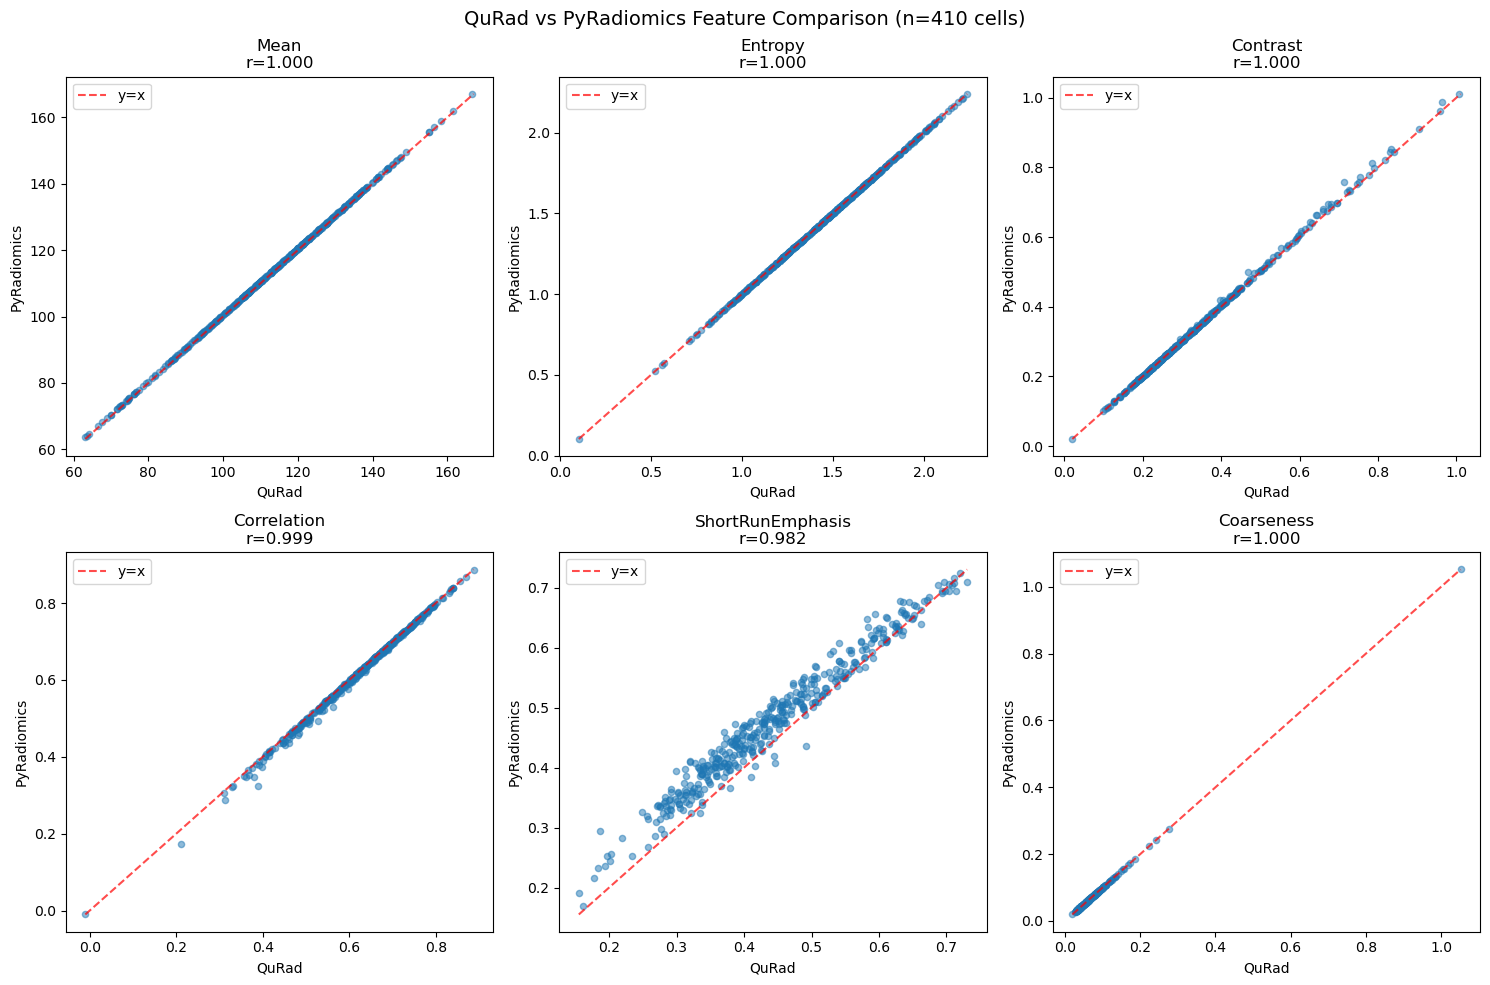


Plot saved to: /Users/tamara/Desktop/PyRadiomics/feature_comparison.png


In [ ]:
import matplotlib.pyplot as plt

def plot_feature_comparison(merged_df, comparison_df):
    """Plot scatter plots comparing QuRad vs PyRadiomics for all matched cells."""
    
    features_to_plot = [
        ('firstorder_Mean', 'original_firstorder_Mean'),
        ('firstorder_Entropy', 'original_firstorder_Entropy'),
        ('glcm_Contrast', 'original_glcm_Contrast'),
        ('glcm_Correlation', 'original_glcm_Correlation'),
        ('glrlm_ShortRunEmphasis', 'original_glrlm_ShortRunEmphasis'),
        ('ngtdm_Coarseness', 'original_ngtdm_Coarseness'),
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (qurad_feat, pyrad_feat) in enumerate(features_to_plot):
        ax = axes[idx]
        
        # Get column names (they have _qurad/_pyrad suffixes after merge)
        qurad_col = f"{qurad_feat}_qurad" if f"{qurad_feat}_qurad" in merged_df.columns else qurad_feat
        pyrad_col = f"{pyrad_feat}_pyrad" if f"{pyrad_feat}_pyrad" in merged_df.columns else pyrad_feat
        
        if qurad_col in merged_df.columns and pyrad_col in merged_df.columns:
            x = merged_df[qurad_col].values
            y = merged_df[pyrad_col].values
            
            # Plot all cells
            ax.scatter(x, y, alpha=0.5, s=20)
            
            # Add diagonal line
            min_val = min(x.min(), y.min())
            max_val = max(x.max(), y.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='y=x')
            
            # Get correlation from comparison_df
            feat_data = comparison_df[(comparison_df['feature'] == qurad_feat) & 
                                      (comparison_df['pyrad_feature'] == pyrad_feat)]
            corr = feat_data.iloc[0]['correlation'] if len(feat_data) > 0 else np.corrcoef(x, y)[0, 1]
            
            ax.set_xlabel('QuRad')
            ax.set_ylabel('PyRadiomics')
            feature_name = qurad_feat.split('_', 1)[1]
            ax.set_title(f'{feature_name}\nr={corr:.3f}')
            ax.legend()
    
    plt.suptitle(f'QuRad vs PyRadiomics Feature Comparison (n={len(merged_df)} cells)', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_feature_comparison(merged_df, comparison_df)

## Summary & Interpretation

### Expected Differences

Some differences between QuRad and PyRadiomics are expected due to:

1. **Gray level quantization**: Different bin boundary handling
2. **GLCM directions**: QuRad uses 4 directions, PyRadiomics may use different defaults
3. **Shape calculations**: Different algorithms for perimeter/area
4. **Floating point precision**: Minor rounding differences

### Interpreting Results

- **Correlation > 0.95**: Excellent agreement
- **Correlation 0.8-0.95**: Good agreement (implementation differences)
- **Correlation < 0.8**: May indicate algorithmic differences worth investigating

In [ ]:
# Save comparison results
if 'comparison_df' in dir() and comparison_df is not None and len(comparison_df) > 0:
    output_path = BASE_DIR / 'feature_comparison_results.csv'
    comparison_df.to_csv(output_path, index=False)
    print(f"Comparison results saved to: {output_path}")
    
    # Summary statistics
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"Features compared: {len(comparison_df)}")
    print(f"Mean correlation: {comparison_df['correlation'].mean():.4f}")
    print(f"Median correlation: {comparison_df['correlation'].median():.4f}")
    print(f"\nFeatures with correlation > 0.95: {(comparison_df['correlation'] > 0.95).sum()}")
    print(f"Features with correlation 0.8-0.95: {((comparison_df['correlation'] >= 0.8) & (comparison_df['correlation'] <= 0.95)).sum()}")
    print(f"Features with correlation < 0.80: {(comparison_df['correlation'] < 0.80).sum()}")
    
    # Show features with lowest correlation
    if (comparison_df['correlation'] < 0.95).any():
        print("\nFeatures with lowest correlation:")
        display(comparison_df.nsmallest(5, 'correlation')[['feature', 'correlation', 'mean_diff']])

Comparison results saved to: /Users/tamara/Desktop/PyRadiomics/feature_comparison_results.csv

SUMMARY
Features compared: 99
Mean correlation: 0.9528
Median correlation: 0.9996

Features with correlation > 0.95: 79
Features with correlation 0.8-0.95: 11
Features with correlation < 0.80: 9

Features with lowest correlation:


KeyError: "['rel_diff_pct'] not in index"

## Features Missing in PyRadiomics

List all features that are in QuRad but not available in PyRadiomics.


In [ ]:
# Display features only in QuRad (missing in PyRadiomics)
if 'qurad_only' in dir() and len(qurad_only) > 0:
    print(f"Features only in QuRad (missing in PyRadiomics): {len(qurad_only)}\n")
    print("=" * 80)
    
    # Group by feature class
    missing_by_class = {}
    for feat in sorted(qurad_only):
        parts = feat.split('_', 1)
        if len(parts) == 2:
            cls = parts[0]
            if cls not in missing_by_class:
                missing_by_class[cls] = []
            missing_by_class[cls].append(parts[1])
    
    # Display grouped by class
    for cls in sorted(missing_by_class.keys()):
        print(f"\n{cls.upper()} ({len(missing_by_class[cls])} features):")
        for feat_name in sorted(missing_by_class[cls]):
            print(f"  - {cls}_{feat_name}")
    
    print(f"\n" + "=" * 80)
    print(f"Total missing features: {len(qurad_only)}")
else:
    print("Run the comparison cell first to identify missing features.")
